In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [15]:
color_raw = o3d.io.read_image("../dataset/rgb/0000002-000000033516.jpg")
# depth_raw = o3d.io.read_image("../dataset/depth/0000001-000000000000.png")
depth_raw = cv2.imread("../dataset/depth/0000002-000000033369.png")[:,:,0]

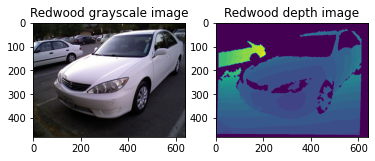

In [16]:
plt.subplot(1, 2, 1)
plt.title('Redwood grayscale image')
plt.imshow(color_raw)
plt.subplot(1, 2, 2)
plt.title('Redwood depth image')
plt.imshow(depth_raw)
plt.show()

In [17]:
def segment_image(img, t):
    img = np.array(img)
    plt.imshow(img)
    plt.show()
    mask = img > t
    img1 = img.copy()
    img1[mask] = 0
    plt.imshow(img1)
    plt.show()
    return img1

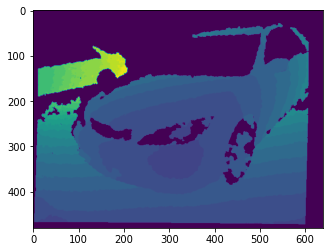

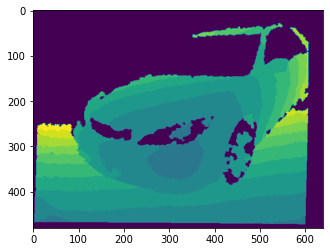

In [18]:
depth_segment = segment_image(depth_raw, 15)
depth_segment = o3d.geometry.Image(depth_segment)

In [19]:
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, depth_segment)
print(rgbd_image)

RGBDImage of size 
Color image : 640x480, with 1 channels.
Depth image : 640x480, with 1 channels.
Use numpy.asarray to access buffer data.


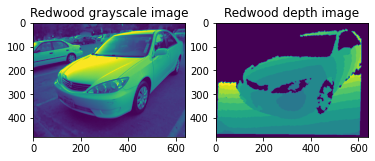

In [20]:
plt.subplot(1, 2, 1)
plt.title('Redwood grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('Redwood depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [21]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault))
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

In [22]:
o3d.io.write_point_cloud('car1.pcd',pcd,
                        write_ascii=False,compressed=True,print_progress=True)

True